# Minimum Wage and Unemployment in Europe

## Project Overview
This project analyzes the relationship between minimum wage levels and unemployment rates across European countries from 2003 to 2025.

## Data Sources
- Minimum wage data: Eurostat API (earn_mw_cur)
- Unemployment rate data: Eurostat API (une_rt_a)
- Exchange rate data: Eurostat API (ert_bil_eur_a)

## Research Question
What is the relationship between minimum wage levels and unemployment rates in Europe?

## Main Finding
A statistically significant negative correlation exists between minimum wage and unemployment rate (slope = -0.003, R² = 0.12, p < 0.05).


## 1. Data Collection
Download minimum wage, unemployment rate, and exchange rate data from the Eurostat API.


In [1]:
import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")

import requests

def test_eurostat_api(dataset_code, label):
    """Test if a Eurostat dataset is accessible via API"""
    url = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset_code}?format=JSON&lang=EN"

    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            data = response.json()
            dimensions = list(data['dimension'].keys())
            n_values = len(data['value'])
            print(f"OK {label} ({dataset_code})")
            print(f"   -> Successfully downloaded, {n_values} data points in total")
            print(f"   -> Dimensions: {dimensions}\n")
            return True
        else:
            print(f"FAILED {label} ({dataset_code}): HTTP {response.status_code}\n")
            return False
    except Exception as e:
        print(f"FAILED {label} ({dataset_code}): {e}\n")
        return False


print("=== Eurostat API Access Verification ===\n")

results = []
results.append(test_eurostat_api("earn_mw_cur", "Minimum Wage Data"))
results.append(test_eurostat_api("lfsi_emp_a",  "Employment Rate Data"))
results.append(test_eurostat_api("nama_10_gdp", "GDP Data"))
results.append(test_eurostat_api("une_rt_a",    "Unemployment Rate Data"))

print(f"Verification result: {sum(results)}/4 datasets accessible")


=== Eurostat API Access Verification ===

OK Minimum Wage Data (earn_mw_cur)
   -> Successfully downloaded, 4484 data points in total
   -> Dimensions: ['freq', 'currency', 'geo', 'time']

OK Employment Rate Data (lfsi_emp_a)
   -> Successfully downloaded, 45624 data points in total
   -> Dimensions: ['freq', 'indic_em', 'sex', 'age', 'unit', 'geo', 'time']

OK GDP Data (nama_10_gdp)
   -> Successfully downloaded, 1113318 data points in total
   -> Dimensions: ['freq', 'unit', 'na_item', 'geo', 'time']

OK Unemployment Rate Data (une_rt_a)
   -> Successfully downloaded, 39708 data points in total
   -> Dimensions: ['freq', 'age', 'unit', 'sex', 'geo', 'time']

Verification result: 4/4 datasets accessible


In [2]:
import pandas as pd
def eurostat_to_dataframe(dataset_code):
    url = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset_code}?format=JSON&lang=EN"
    response = requests.get(url, timeout=30)
    data = response.json()

    dims = data['dimension']
    dim_names = list(dims.keys())

    dim_indices = []
    for dim in dim_names:
        categories = dims[dim]['category']
        index_map = {v: k for k, v in categories['index'].items()}
        dim_indices.append(index_map)

    rows = []
    for pos_str, value in data['value'].items():
        pos = int(pos_str)
        coords = []
        for i in range(len(dim_names) - 1, -1, -1):
            size = len(dim_indices[i])
            coords.insert(0, dim_indices[i][pos % size])
            pos //= size
        rows.append(coords + [value])

    df = pd.DataFrame(rows, columns=dim_names + ['value'])
    return df

mw_df = eurostat_to_dataframe("earn_mw_cur")
print(mw_df.head(10))
print("Shape:", mw_df.shape)


  freq currency geo     time  value
0    S      EUR  AL  1999-S2   45.0
1    S      EUR  AL  2000-S1   47.0
2    S      EUR  AL  2000-S2   52.0
3    S      EUR  AL  2001-S1   53.0
4    S      EUR  AL  2001-S2   60.0
5    S      EUR  AL  2002-S1   63.0
6    S      EUR  AL  2002-S2   68.0
7    S      EUR  AL  2003-S1   67.0
8    S      EUR  AL  2003-S2   74.0
9    S      EUR  AL  2004-S1   75.0
Shape: (4484, 5)


## 2. Data Cleaning
Clean and standardize the data, convert all currencies to EUR, and merge into a panel dataset.


In [3]:

mw_clean = mw_df[mw_df['freq'] == 'S'].copy()
mw_clean = mw_clean[mw_clean['time'].str.endswith('S1')].copy()
mw_clean['year'] = mw_clean['time'].str[:4].astype(int)
mw_clean = mw_clean[['geo', 'year', 'value']].rename(columns={'value': 'min_wage'})

print(mw_clean.head(10))
print("Shape:", mw_clean.shape)


   geo  year  min_wage
1   AL  2000      47.0
3   AL  2001      53.0
5   AL  2002      63.0
7   AL  2003      67.0
9   AL  2004      75.0
11  AL  2005      85.0
13  AL  2006      96.0
15  AL  2007     113.0
17  AL  2008     131.0
19  AL  2009     137.0
Shape: (2278, 3)


In [4]:

une_df = eurostat_to_dataframe("une_rt_a")
print(une_df.head())
print("Dimensions:", une_df.columns.tolist())


  freq     age    unit sex geo  time  value
0    A  Y15-24  PC_ACT   F  AT  2009   10.5
1    A  Y15-24  PC_ACT   F  AT  2010    9.8
2    A  Y15-24  PC_ACT   F  AT  2011    9.5
3    A  Y15-24  PC_ACT   F  AT  2012    9.6
4    A  Y15-24  PC_ACT   F  AT  2013   10.4
Dimensions: ['freq', 'age', 'unit', 'sex', 'geo', 'time', 'value']


In [5]:
une_clean = une_df[
    (une_df['age'] == 'TOTAL') &
    (une_df['sex'] == 'T') &
    (une_df['unit'] == 'PC_ACT')
].copy()

une_clean['year'] = une_clean['time'].astype(int)
une_clean = une_clean[['geo', 'year', 'value']].rename(columns={'value': 'unemployment_rate'})

print(une_clean.head(10))
print("Shape:", une_clean.shape)


Empty DataFrame
Columns: [geo, year, unemployment_rate]
Index: []
Shape: (0, 3)


In [6]:
print("age_all_value:", une_df['age'].unique())
print("sex_all_value:", une_df['sex'].unique())
print("unit_all_value:", une_df['unit'].unique())


age_all_value: <StringArray>
['Y15-24', 'Y15-29', 'Y15-74', 'Y20-64', 'Y25-54', 'Y25-74', 'Y55-74']
Length: 7, dtype: str
sex_all_value: <StringArray>
['F', 'M', 'T']
Length: 3, dtype: str
unit_all_value: <StringArray>
['PC_ACT', 'PC_POP', 'THS_PER']
Length: 3, dtype: str


In [7]:
une_clean = une_df[
    (une_df['age'] == 'Y15-74') &
    (une_df['sex'] == 'T') &
    (une_df['unit'] == 'PC_ACT')
].copy()

une_clean['year'] = une_clean['time'].astype(int)
une_clean = une_clean[['geo', 'year', 'value']].rename(columns={'value': 'unemployment_rate'})

print(une_clean.head(10))
print("Shape:", une_clean.shape)


      geo  year  unemployment_rate
12610  AT  2009                5.7
12611  AT  2010                5.2
12612  AT  2011                4.9
12613  AT  2012                5.2
12614  AT  2013                5.7
12615  AT  2014                6.0
12616  AT  2015                6.1
12617  AT  2016                6.5
12618  AT  2017                5.9
12619  AT  2018                5.2
Shape: (635, 3)


In [8]:

panel = pd.merge(mw_clean, une_clean, on=['geo', 'year'], how='inner')

print(panel.head(10))
print("Shape:", panel.shape)
print("The_amount_of_country:", panel['geo'].nunique())
print("Year_range:", panel['year'].min(), "-", panel['year'].max())


  geo  year  min_wage  unemployment_rate
0  BE  2009    1388.0                8.0
1  BE  2010    1388.0                8.4
2  BE  2011    1415.0                7.2
3  BE  2012    1444.0                7.6
4  BE  2013    1502.0                8.6
5  BE  2014    1502.0                8.7
6  BE  2015    1502.0                8.7
7  BE  2016    1502.0                7.9
8  BE  2017    1532.0                7.2
9  BE  2018    1563.0                6.0
Shape: (1238, 4)
The_amount_of_country: 26
Year_range: 2003 - 2025


In [9]:

er_df = eurostat_to_dataframe("ert_bil_eur_a")
print(er_df.head())
print("dimension:", er_df.columns.tolist())
print("currency_value:", er_df['currency'].unique() if 'currency' in er_df.columns else "None")


  freq statinfo unit currency  time    value
0    A      AVG  NAC      AED  2001  3.27810
1    A      AVG  NAC      AED  2002  3.49425
2    A      AVG  NAC      AED  2003  4.19886
3    A      AVG  NAC      AED  2004  4.58488
4    A      AVG  NAC      AED  2005  4.55976
dimension: ['freq', 'statinfo', 'unit', 'currency', 'time', 'value']
currency_value: <StringArray>
['AED', 'AFN', 'ALL', 'AMD', 'AOA', 'ARS', 'AUD', 'AWG', 'AZN', 'BAM',
 ...
 'WST', 'XAF', 'XCD', 'XCG', 'XOF', 'XPF', 'YER', 'ZAR', 'ZMW', 'ZWG']
Length: 151, dtype: str


In [10]:

currencies_needed = ['CZK', 'HUF', 'MKD', 'RSD', 'TRY']

er_clean = er_df[
    (er_df['currency'].isin(currencies_needed)) &
    (er_df['statinfo'] == 'AVG') &
    (er_df['unit'] == 'NAC')
].copy()

er_clean['year'] = er_clean['time'].astype(int)
er_clean = er_clean[['currency', 'year', 'value']].rename(columns={'value': 'exchange_rate'})

print(er_clean.head(10))
print("Shape:", er_clean.shape)


    currency  year  exchange_rate
871      CZK  1993         34.169
872      CZK  1994         34.151
873      CZK  1995         34.696
874      CZK  1996         34.457
875      CZK  1997         35.930
876      CZK  1998         36.049
877      CZK  1999         36.884
878      CZK  2000         35.599
879      CZK  2001         34.068
880      CZK  2002         30.804
Shape: (173, 3)


In [11]:

geo_to_currency = {
    'CZ': 'CZK',
    'HU': 'HUF',
    'MK': 'MKD',
    'RS': 'RSD',
    'TR': 'TRY'
}

panel['currency'] = panel['geo'].map(geo_to_currency)


panel_with_er = pd.merge(panel, er_clean, on=['currency', 'year'], how='left')

panel_with_er['min_wage_eur'] = panel_with_er.apply(
    lambda row: row['min_wage'] / row['exchange_rate']
    if pd.notna(row['exchange_rate'])
    else row['min_wage'],
    axis=1
)

panel_final = panel_with_er[['geo', 'year', 'min_wage_eur', 'unemployment_rate']].copy()

print(panel_final.head(10))
print("Shape:", panel_final.shape)


  geo  year  min_wage_eur  unemployment_rate
0  BE  2009        1388.0                8.0
1  BE  2010        1388.0                8.4
2  BE  2011        1415.0                7.2
3  BE  2012        1444.0                7.6
4  BE  2013        1502.0                8.6
5  BE  2014        1502.0                8.7
6  BE  2015        1502.0                8.7
7  BE  2016        1502.0                7.9
8  BE  2017        1532.0                7.2
9  BE  2018        1563.0                6.0
Shape: (1238, 4)


## 3. Visualization
Visualize the relationship between minimum wage and unemployment rate across countries and regions.


### Figure 1: Minimum Wage vs Unemployment Rate in Europe (2003–2025)

This scatter plot provides an initial visual overview of the relationship between minimum wage levels and unemployment rates across European countries. Each point represents a country-year observation. The graph suggests that the relationship is not purely mechanical: observations are widely dispersed, and countries with similar minimum wage levels can have substantially different unemployment rates. This indicates that minimum wage alone cannot fully explain unemployment differences across Europe.


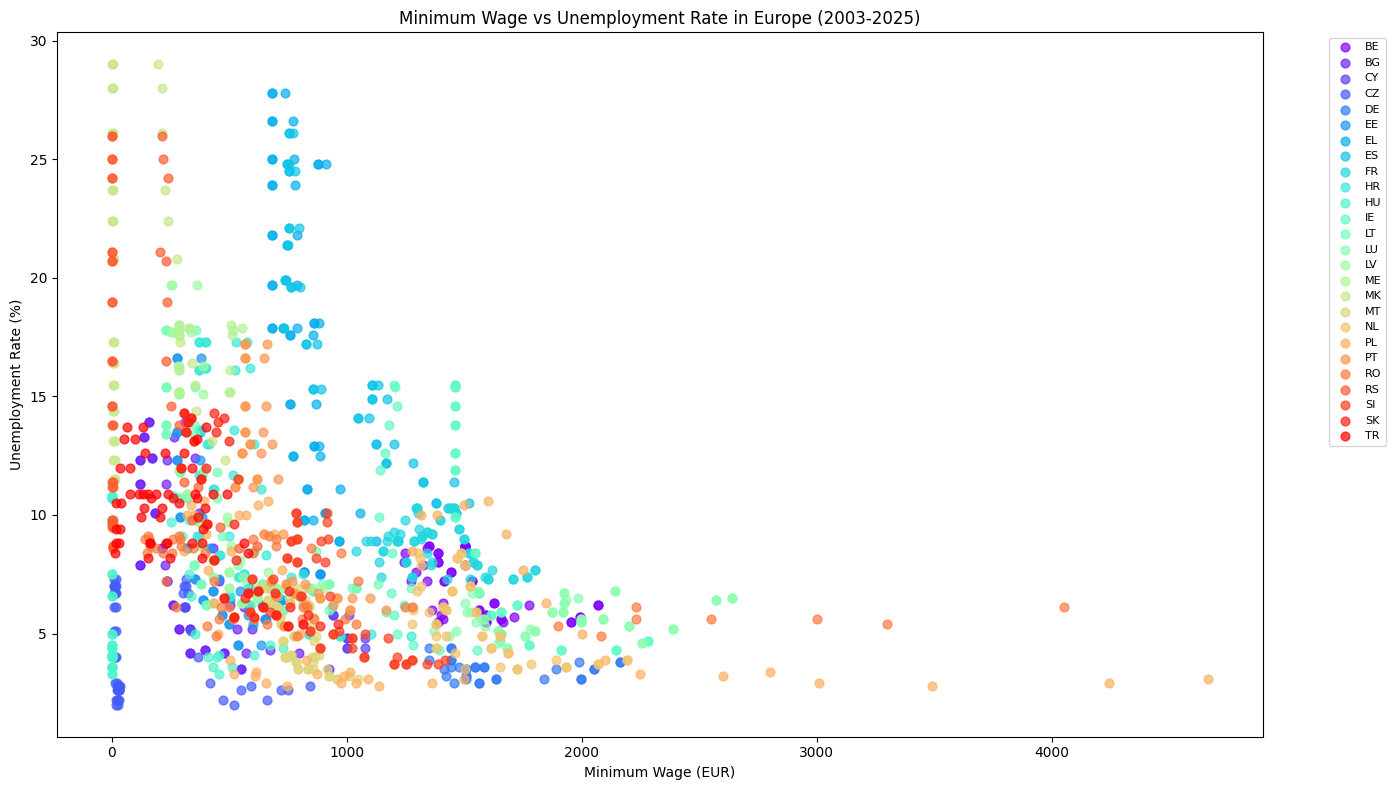

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))

countries = sorted(panel_final['geo'].unique())
colors = cm.rainbow(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):
    data = panel_final[panel_final['geo'] == country]
    ax.scatter(data['min_wage_eur'], data['unemployment_rate'],
               label=country, color=colors[i], alpha=0.7, s=40)

ax.set_xlabel('Minimum Wage (EUR)')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('Minimum Wage vs Unemployment Rate in Europe (2003-2025)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


### Figure 2: Minimum Wage and Unemployment Over Time in Selected Countries

This figure compares the development of minimum wages and unemployment rates in selected European countries. The upper panel shows that minimum wages generally increased over time, although the level and speed of growth differ across countries. The lower panel shows that unemployment rates fluctuated more strongly, especially around periods of economic stress. This contrast suggests that unemployment is influenced by broader macroeconomic conditions, not only by minimum wage policy.


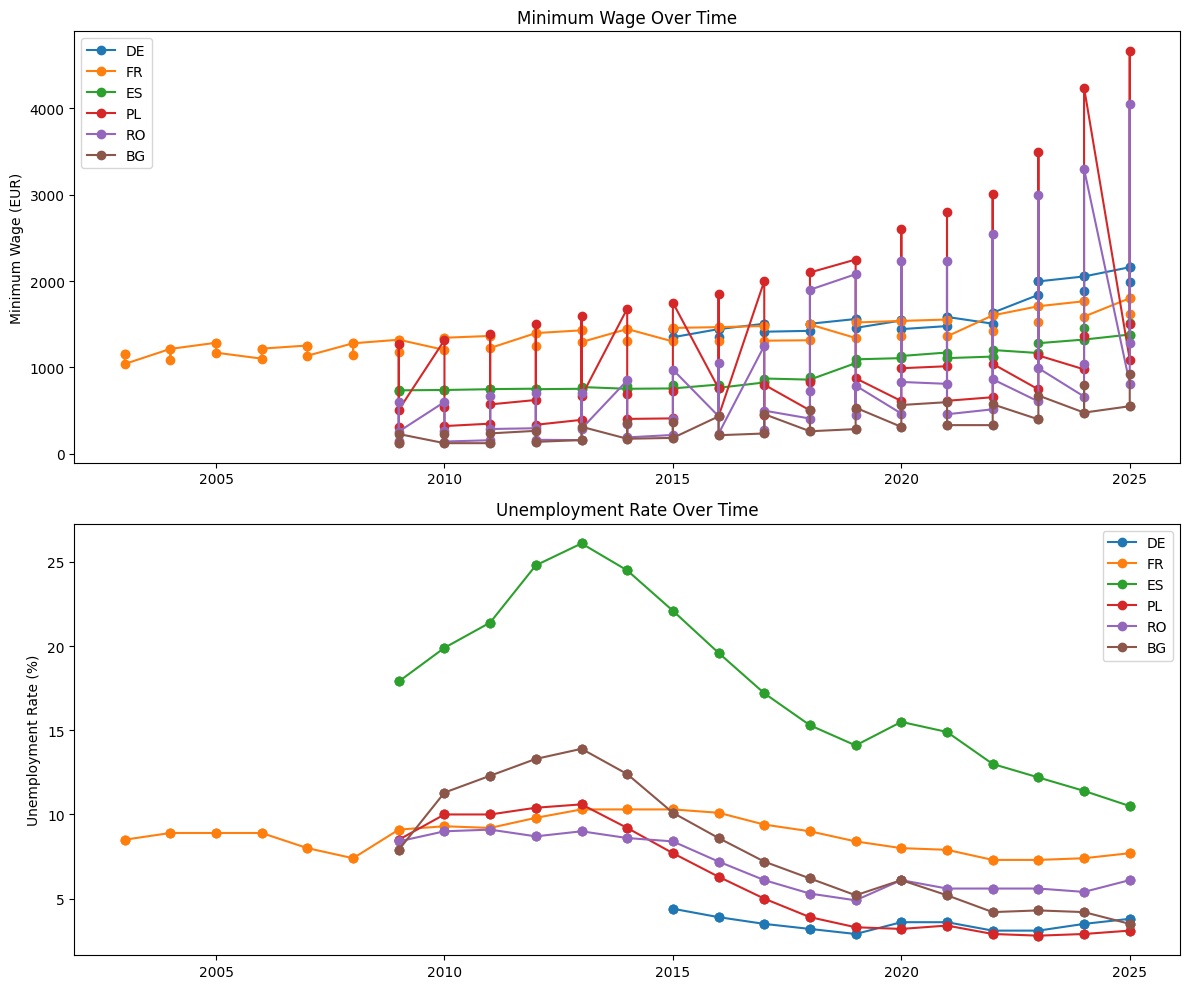

In [13]:

selected = ['DE', 'FR', 'ES', 'PL', 'RO', 'BG']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

for country in selected:
    data = panel_final[panel_final['geo'] == country].sort_values('year')
    ax1.plot(data['year'], data['min_wage_eur'], marker='o', label=country)
    ax2.plot(data['year'], data['unemployment_rate'], marker='o', label=country)

ax1.set_title('Minimum Wage Over Time')
ax1.set_ylabel('Minimum Wage (EUR)')
ax1.legend()

ax2.set_title('Unemployment Rate Over Time')
ax2.set_ylabel('Unemployment Rate (%)')
ax2.legend()

plt.tight_layout()
plt.show()


## 4. Regression Analysis

### 4.1 Simple Linear Regression

Run a simple linear regression to quantify the relationship between minimum wage and unemployment rate.



In [14]:
from scipy import stats


slope, intercept, r_value, p_value, std_err = stats.linregress(
    panel_final['min_wage_eur'],
    panel_final['unemployment_rate']
)

print(f"slope (slope): {slope:.4f}")
print(f"intercept (intercept): {intercept:.4f}")
print(f"R² : {r_value**2:.4f}")
print(f"P_value (p-value): {p_value:.4f}")


slope (slope): -0.0030
intercept (intercept): 11.7060
R² : 0.1194
P_value (p-value): 0.0000


In [15]:
slope, intercept, r_value, p_value, std_err = stats.linregress(
    panel_final['min_wage_eur'],
    panel_final['unemployment_rate']
)

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nInterpretation:")
print(f"A 1 EUR increase in minimum wage is associated with a {abs(slope):.4f} percentage point decrease in unemployment rate.")
print(f"The relationship is statistically significant (p < 0.05).")
print(f"Minimum wage explains {r_value**2*100:.1f}% of the variation in unemployment rate.")


Slope: -0.0030
Intercept: 11.7060
R²: 0.1194
P-value: 0.0000

Interpretation:
A 1 EUR increase in minimum wage is associated with a 0.0030 percentage point decrease in unemployment rate.
The relationship is statistically significant (p < 0.05).
Minimum wage explains 11.9% of the variation in unemployment rate.


### Figure 3: Minimum Wage vs Unemployment Rate with OLS Trendline

This interactive scatter plot adds an OLS trendline to summarize the average relationship between minimum wages and unemployment rates. The trendline suggests a negative association in the pooled data: higher minimum wages are associated with lower unemployment rates on average. However, the points remain widely dispersed around the line, so the relationship should be interpreted as correlation rather than causation. This motivates the use of additional control variables in the next part of the analysis.


In [16]:
import plotly.express as px

fig = px.scatter(
    panel_final,
    x='min_wage_eur',
    y='unemployment_rate',
    color='geo',
    hover_data=['geo', 'year', 'min_wage_eur', 'unemployment_rate'],
    title='Minimum Wage vs Unemployment Rate in Europe (2003-2025)',
    labels={
        'min_wage_eur': 'Minimum Wage (EUR)',
        'unemployment_rate': 'Unemployment Rate (%)',
        'geo': 'Country'
    },
    trendline='ols'
)

fig.show()


### 4.2 Multiple Regression with GDP as Control Variable

The simple regression in Section 4.1 shows the raw relationship between minimum wages and unemployment. However, this relationship may be affected by differences in economic development. Richer countries can usually afford higher minimum wages and may also have stronger labor markets, which means that GDP could influence both variables at the same time.

To address this, we add GDP as a control variable. The multiple regression estimates the relationship between minimum wage and unemployment while holding GDP constant. We also use log(GDP), because GDP differs greatly across countries and the logarithmic transformation reduces extreme scale differences. This makes the regression easier to interpret and helps reduce the influence of very large economies.


In [17]:
# Download GDP data
gdp_df = eurostat_to_dataframe("nama_10_gdp")
print(gdp_df.head())
print("Dimensions:", gdp_df.columns.tolist())
print("na_item values:", gdp_df['na_item'].unique())
print("unit values:", gdp_df['unit'].unique())


  freq        unit na_item geo  time   value
0    A  CLV05_MEUR     B1G  AL  1995  3422.5
1    A  CLV05_MEUR     B1G  AL  1996  3675.6
2    A  CLV05_MEUR     B1G  AL  1997  3279.3
3    A  CLV05_MEUR     B1G  AL  1998  3538.0
4    A  CLV05_MEUR     B1G  AL  1999  4031.1
Dimensions: ['freq', 'unit', 'na_item', 'geo', 'time', 'value']
na_item values: <StringArray>
[        'B1G',        'B1GQ',         'D21',      'D21X31',         'D31',
          'P3',     'P31_S13',     'P31_S14', 'P31_S14_S15',     'P31_S15',
     'P32_S13',       'P3_P5',       'P3_P6',      'P3_S13',         'P41',
        'P51G',         'P5G',          'P6',         'P61',         'P62',
          'P7',         'P71',         'P72',     'P52_P53',       'B2A3G',
          'D1',         'D11',         'D12',          'D2',        'D2X3',
          'D3',         'P52',         'P53',      'P61X71',      'P62X72',
        'P6X7',         'YA0',         'YA1',         'YA2']
Length: 39, dtype: str
unit values: <String

In [18]:
gdp_clean = gdp_df[
    (gdp_df['na_item'] == 'B1G') &
    (gdp_df['unit'] == 'CP_MEUR')
].copy()

gdp_clean['year'] = gdp_clean['time'].astype(int)
gdp_clean = gdp_clean[['geo', 'year', 'value']].rename(columns={'value': 'gdp'})

print(gdp_clean.head(10))
print("Shape:", gdp_clean.shape)


       geo  year     gdp
436276  AL  1995  2063.1
436277  AL  1996  2350.6
436278  AL  1997  1809.6
436279  AL  1998  2007.6
436280  AL  1999  2703.3
436281  AL  2000  3348.7
436282  AL  2001  3950.7
436283  AL  2002  4160.7
436284  AL  2003  4381.8
436285  AL  2004  5113.7
Shape: (1432, 3)


In [19]:
import statsmodels.api as sm

# Merge GDP into panel data
panel_gdp = pd.merge(panel_final, gdp_clean, on=['geo', 'year'], how='inner')
print("Shape after merge:", panel_gdp.shape)

# Multiple regression: unemployment ~ min_wage + GDP
X = panel_gdp[['min_wage_eur', 'gdp']]
X = sm.add_constant(X)
y = panel_gdp['unemployment_rate']

model = sm.OLS(y, X).fit()
print(model.summary())


Shape after merge: (1238, 5)
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     83.92
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           6.69e-35
Time:                        18:13:12   Log-Likelihood:                -3756.6
No. Observations:                1238   AIC:                             7519.
Df Residuals:                    1235   BIC:                             7535.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           11.

In [20]:
panel_gdp['log_gdp'] = np.log(panel_gdp['gdp'])

X = panel_gdp[['min_wage_eur', 'log_gdp']]
X = sm.add_constant(X)
y = panel_gdp['unemployment_rate']

model2 = sm.OLS(y, X).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     85.05
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.49e-35
Time:                        18:13:12   Log-Likelihood:                -3755.6
No. Observations:                1238   AIC:                             7517.
Df Residuals:                    1235   BIC:                             7533.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           13.3375      1.106     12.063   

### Figure 4: Partial Regression Plots

These partial regression plots visualize the multiple regression results after controlling for GDP. The left plot shows the relationship between minimum wage and unemployment after removing the effect of log(GDP) from both variables. The right plot shows the relationship between GDP and unemployment after controlling for minimum wage. This helps distinguish the association of minimum wage from the broader effect of economic size and development.


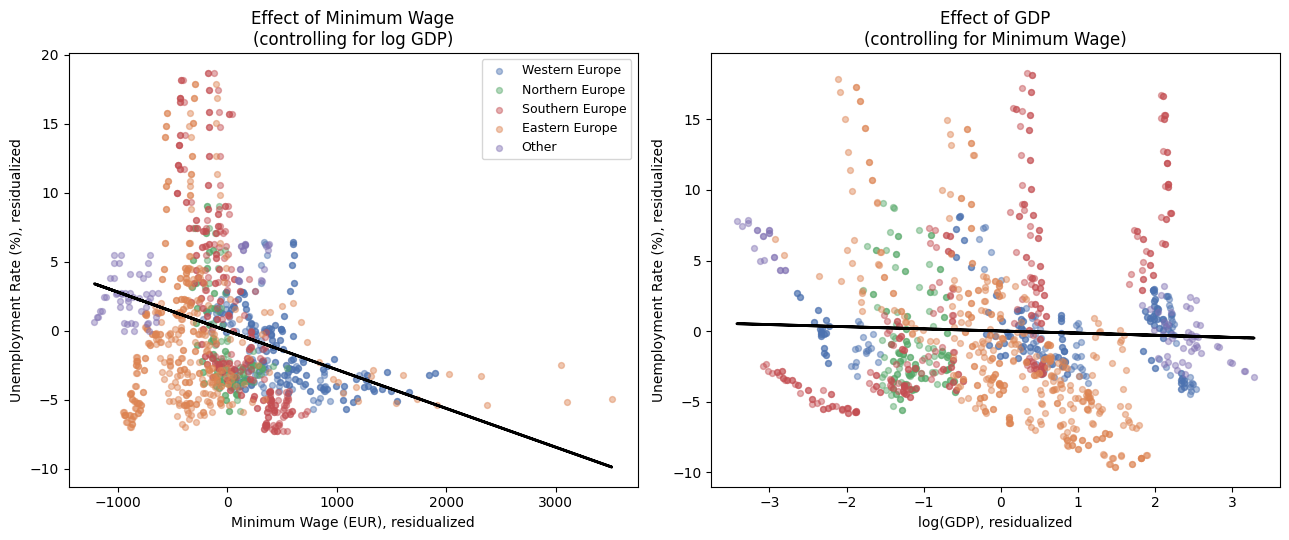

In [21]:
import matplotlib.pyplot as plt

e_y1 = sm.OLS(y, sm.add_constant(panel_gdp['log_gdp'])).fit().resid
e_x1 = sm.OLS(panel_gdp['min_wage_eur'], sm.add_constant(panel_gdp['log_gdp'])).fit().resid
e_y2 = sm.OLS(y, sm.add_constant(panel_gdp['min_wage_eur'])).fit().resid
e_x2 = sm.OLS(panel_gdp['log_gdp'], sm.add_constant(panel_gdp['min_wage_eur'])).fit().resid


region_map = {
    'Western Europe': ['BE', 'DE', 'FR', 'IE', 'LU', 'NL'],
    'Northern Europe': ['EE', 'LT', 'LV'],
    'Southern Europe': ['CY', 'EL', 'ES', 'HR', 'MT', 'PT', 'SI'],
    'Eastern Europe': ['BG', 'CZ', 'HU', 'MK', 'PL', 'RO', 'RS', 'SK'],
    'Other': ['ME', 'TR']
}
geo_to_region = {geo: region for region, geos in region_map.items() for geo in geos}
regions = panel_gdp['geo'].map(geo_to_region)

colors = {
    'Western Europe': '#4C72B0',
    'Northern Europe': '#55A868',
    'Southern Europe': '#C44E52',
    'Eastern Europe': '#DD8452',
    'Other': '#8172B3'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

for region, color in colors.items():
    mask = (regions == region).values
    ax1.scatter(e_x1[mask], e_y1[mask], alpha=0.45, s=18, color=color, label=region)
    ax2.scatter(e_x2[mask], e_y2[mask], alpha=0.45, s=18, color=color)

b1 = sm.OLS(e_y1, sm.add_constant(e_x1)).fit().params.iloc[1]
ax1.plot(e_x1, b1 * e_x1, color='black', linewidth=2)
ax1.set_xlabel('Minimum Wage (EUR), residualized')
ax1.set_ylabel('Unemployment Rate (%), residualized')
ax1.set_title('Effect of Minimum Wage\n(controlling for log GDP)')
ax1.legend(fontsize=9)

b2 = sm.OLS(e_y2, sm.add_constant(e_x2)).fit().params.iloc[1]
ax2.plot(e_x2, b2 * e_x2, color='black', linewidth=2)
ax2.set_xlabel('log(GDP), residualized')
ax2.set_ylabel('Unemployment Rate (%), residualized')
ax2.set_title('Effect of GDP\n(controlling for Minimum Wage)')

plt.tight_layout()
plt.show()



### Figure 5: Animated Bubble Chart with GDP

This animated bubble chart shows how the relationship between minimum wage and unemployment evolved over time. Each bubble represents a country-year observation, while the bubble size represents GDP. The animation highlights that many countries experienced rising minimum wages over the observed period, while unemployment rates moved less uniformly. Larger economies can also be compared with smaller ones, which makes the chart useful for identifying broad patterns and outliers.


In [22]:
plot_df = panel_gdp.copy()
plot_df = plot_df.sort_values('year')

all_combos = pd.MultiIndex.from_product(
    [plot_df['geo'].unique(), plot_df['year'].unique()],
    names=['geo', 'year']
).to_frame(index=False)

plot_full = all_combos.merge(plot_df, on=['geo', 'year'], how='left')


plot_full['gdp'] = plot_full['gdp'].fillna(0)
plot_full['min_wage_eur'] = plot_full['min_wage_eur'].fillna(0)
plot_full['unemployment_rate'] = plot_full['unemployment_rate'].fillna(0)

plot_full = plot_full.sort_values('year')
plot_full['year'] = plot_full['year'].astype(str)

fig = px.scatter(
    plot_full,
    x='min_wage_eur',
    y='unemployment_rate',
    color='geo',
    size='gdp',
    size_max=45,
    hover_name='geo',
    animation_frame='year',
    animation_group='geo',
    range_x=[0, plot_full['min_wage_eur'].max() * 1.05],
    range_y=[0, plot_full['unemployment_rate'].max() * 1.05],
    labels={
        'min_wage_eur': 'Minimum Wage (EUR)',
        'unemployment_rate': 'Unemployment Rate (%)',
        'geo': 'Country',
        'gdp': 'GDP (million EUR)'
    },
    title='Minimum Wage vs Unemployment, bubble size = GDP (2003-2025)'
)
fig.show()




## 5. Regional Analysis
Divide countries into geographical regions and analyze trends within each region.


### Figure 6: Minimum Wage in Europe Over Time

The choropleth map visualizes the geographical distribution of minimum wages across Europe over time. The map highlights large and persistent regional differences, especially between Western and Eastern Europe. Western European countries generally have higher minimum wages, while several Eastern European countries show strong growth over time. This supports the idea of partial wage convergence within Europe.


In [23]:
iso2_to_iso3 = {
    'AT': 'AUT',
    'BE': 'BEL',
    'BG': 'BGR',
    'CH': 'CHE',
    'CY': 'CYP',
    'CZ': 'CZE',
    'DE': 'DEU',
    'DK': 'DNK',
    'EE': 'EST',
    'EL': 'GRC',
    'ES': 'ESP',
    'FI': 'FIN',
    'FR': 'FRA',
    'HR': 'HRV',
    'HU': 'HUN',
    'IE': 'IRL',
    'IS': 'ISL',
    'IT': 'ITA',
    'LT': 'LTU',
    'LU': 'LUX',
    'LV': 'LVA',
    'MT': 'MLT',
    'NL': 'NLD',
    'NO': 'NOR',
    'PL': 'POL',
    'PT': 'PRT',
    'RO': 'ROU',
    'SE': 'SWE',
    'SI': 'SVN',
    'SK': 'SVK',
    'UK': 'GBR',
    'AL': 'ALB'
}


panel_map = panel_final.copy()
panel_map['iso3'] = panel_map['geo'].map(iso2_to_iso3)
panel_map = panel_map.dropna(subset=['iso3'])

panel_map = panel_map.sort_values('year')
fig = px.choropleth(
    panel_map,
    locations='iso3',
    color='min_wage_eur',
    hover_name='geo',
    hover_data={'min_wage_eur': True, 'unemployment_rate': True},
    animation_frame='year',
    scope='europe',
    color_continuous_scale='RdYlGn',
    title='Minimum Wage in Europe Over Time',
    labels={'min_wage_eur': 'Minimum Wage (EUR)'},
    width=900,
    height=600,
    range_color=[0, panel_map['min_wage_eur'].max()]
)

fig.show()


In [24]:
fig.write_html("minimum_wage_map.html")
logging.info("Files saved successfully")


INFO - Files saved successfully


In [25]:

region_map = {
    'Western Europe': ['BE', 'DE', 'FR', 'IE', 'LU', 'NL'],
    'Northern Europe': ['EE', 'LT', 'LV'],
    'Southern Europe': ['CY', 'EL', 'ES', 'HR', 'MT', 'PT', 'SI'],
    'Eastern Europe': ['BG', 'CZ', 'HU', 'MK', 'PL', 'RO', 'RS', 'SK'],
    'Other': ['ME', 'TR']
}


geo_to_region = {}
for region, countries in region_map.items():
    for country in countries:
        geo_to_region[country] = region

panel_final['region'] = panel_final['geo'].map(geo_to_region)

region_avg = panel_final.groupby(['region', 'year']).agg(
    min_wage_eur=('min_wage_eur', 'mean'),
    unemployment_rate=('unemployment_rate', 'mean')
).reset_index()

print(region_avg.head(10))


           region  year  min_wage_eur  unemployment_rate
0  Eastern Europe  2009    286.431259           8.866667
1  Eastern Europe  2010    263.800324          11.971429
2  Eastern Europe  2011    278.337375          12.471429
3  Eastern Europe  2012    293.256287          12.857143
4  Eastern Europe  2013    279.903687          14.700000
5  Eastern Europe  2014    299.845726          13.200000
6  Eastern Europe  2015    320.319821          11.812500
7  Eastern Europe  2016    341.067500          10.112500
8  Eastern Europe  2017    374.466524           8.787500
9  Eastern Europe  2018    440.096873           7.787500


### Figure 7: Average Minimum Wage by Region Over Time

This regional line chart compares average minimum wage levels across European regions. All regions show an upward trend, but the level of minimum wages remains very different across Europe. Western Europe consistently has the highest average minimum wage, while Eastern Europe starts from a much lower level but grows noticeably over time. The graph therefore illustrates both persistent regional gaps and gradual convergence.


In [26]:
fig1 = px.line(
    region_avg,
    x='year',
    y='min_wage_eur',
    color='region',
    title='Average Minimum Wage by Region Over Time',
    labels={'min_wage_eur': 'Minimum Wage (EUR)', 'year': 'Year', 'region': 'Region'}
)
fig1.show()


### Figure 8: Average Unemployment Rate by Region Over Time

This graph compares average unemployment rates across European regions. Unlike minimum wages, unemployment rates do not follow a simple upward trend. Instead, they fluctuate over time and across regions, reflecting macroeconomic shocks and country-specific labor market conditions. This supports the interpretation that unemployment cannot be explained by minimum wage policy alone.


In [27]:
fig2 = px.line(
    region_avg,
    x='year',
    y='unemployment_rate',
    color='region',
    title='Average Unemployment Rate by Region Over Time',
    labels={'unemployment_rate': 'Unemployment Rate (%)', 'year': 'Year', 'region': 'Region'}
)
fig2.show()


In [28]:

panel_final.to_csv('panel_data.csv', index=False)
region_avg.to_csv('region_data.csv', index=False)
logging.info("Files saved successfully")


INFO - Files saved successfully


## 6. Interactive Streamlit App
The interactive web application is built using Streamlit, allowing users to explore the data from different perspectives.

# Running the Streamlit Application

This notebook generates:

- `app.py`
- `panel_data.csv`
- `region_data.csv`

After running the notebook from start to finish, launch the Streamlit application with:

```bash
streamlit run app.py
```

Features:
- Filter by region and year range
- Interactive scatter plot with trendline
- Regional trend visualizations


In [ ]:
app_code = """
import streamlit as st
import pandas as pd
import plotly.express as px
from scipy import stats

panel = pd.read_csv('panel_data.csv')
region_avg = pd.read_csv('region_data.csv')

st.title('Minimum Wage and Unemployment in Europe')

st.sidebar.header('Filters')
selected_region = st.sidebar.selectbox(
    'Select Region',
    ['All'] + sorted(panel['region'].dropna().unique().tolist())
)
selected_years = st.sidebar.slider(
    'Select Year Range',
    int(panel['year'].min()),
    int(panel['year'].max()),
    (2010, 2023)
)

filtered = panel[
    (panel['year'] >= selected_years[0]) &
    (panel['year'] <= selected_years[1])
]
if selected_region != 'All':
    filtered = filtered[filtered['region'] == selected_region]

st.subheader('Minimum Wage vs Unemployment Rate')
fig1 = px.scatter(filtered, x='min_wage_eur', y='unemployment_rate',
    color='geo', hover_data=['geo', 'year'], trendline='ols')
st.plotly_chart(fig1)

st.subheader('Trends by Region')
fig2 = px.line(region_avg, x='year', y='min_wage_eur', color='region')
st.plotly_chart(fig2)
fig3 = px.line(region_avg, x='year', y='unemployment_rate', color='region')
st.plotly_chart(fig3)
"""

with open('app.py', 'w') as f:
    f.write(app_code)

logging.info("app.py created successfully")



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\adamm\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip
INFO - app.py created successfully


## 7. Conclusion

Our analysis of 26 European countries (2003–2025) finds a statistically
significant **negative** correlation between minimum wage levels and
unemployment rates. In the simple linear regression, a €100 increase in
the monthly minimum wage is associated with a decrease of about 0.30
percentage points in the unemployment rate (p < 0.001), although minimum
wage alone explains only about 12% of the variation in unemployment
(R² ≈ 0.12).

This result is **robust to controlling for economic size**: after adding
log(GDP) as a control variable, the minimum wage coefficient remains
negative and significant (−0.0028, p < 0.001). The partial
regression plot confirms this relationship visually. Our findings are
consistent with Card & Krueger (1994) and Dube, Lester & Reich (2010),
who found no evidence that higher minimum wages increase unemployment.

The regional analysis reveals large and persistent gaps between Western
and Eastern Europe in minimum wage levels. However, the animated
visualization shows Eastern European minimum wages catching up rapidly
in recent years, while unemployment rates across Europe have generally
converged downward since the euro area crisis.

**Limitations.** Our results show correlation, not causation. Reverse
causality is possible: countries with stronger economies can afford both
higher minimum wages and lower unemployment. A causal analysis would
require methods such as difference-in-differences or instrumental
variables, which are beyond the scope of this project. In addition, our
panel does not control for country fixed effects, labor market
institutions, or differences in living costs across countries.
